In [1]:
import os
import sys 
sys.path.append(os.path.abspath(".."))

In [31]:
from src.data_loader import load_data
from src.feature_selection import *
from src.utils import (split_data,get_feature_names,save_model)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data=load_data()

In [9]:
X,y,feature_names,target_names=data

In [10]:
df=pd.DataFrame(X,columns=feature_names)

In [12]:
df["target"]=y

In [13]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# Data split to test and train

In [15]:
X_train,X_test,y_train,y_test=split_data(X,y)

In [16]:
print("Features:", feature_names)
print("Classes:", target_names)

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


In [17]:
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (120, 4)
Test shape: (30, 4)


In [23]:
selector,indices,score=select_univariate(X_train,y_train)

In [24]:
get_feature_names(indices,feature_names)

['petal length (cm)', 'petal width (cm)']

## Plot feature scores

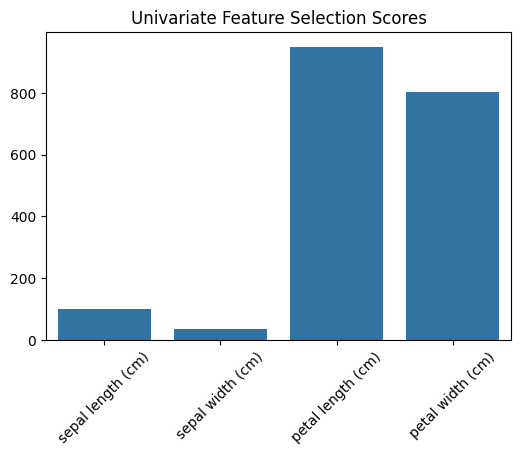

In [25]:
plt.figure(figsize=(6,4))

sns.barplot(x=feature_names, y=score)

plt.title("Univariate Feature Selection Scores")
plt.xticks(rotation=45)
plt.show()

## Random Forest Feature Importance

In [28]:
model,importance,ranked_indices=select_rf_importance(X_train,y_train)

In [36]:
save_model(model,"rf_model2.pkl")

'models/rf_model2.pkl'

In [29]:
rf_features = [feature_names[i] for i in ranked_indices]
rf_features

['petal length (cm)',
 'petal width (cm)',
 'sepal length (cm)',
 'sepal width (cm)']

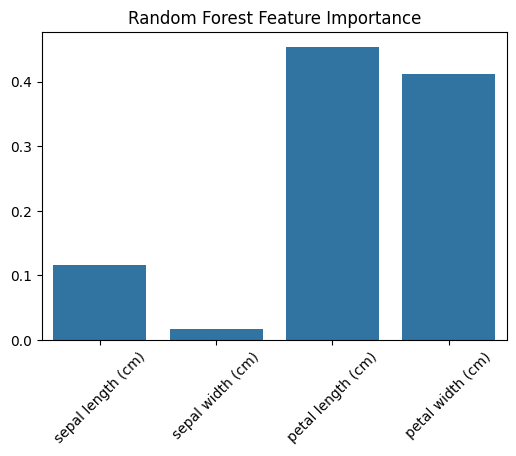

In [30]:
plt.figure(figsize=(6,4))

sns.barplot(x=feature_names, y=importance)

plt.title("Random Forest Feature Importance")
plt.xticks(rotation=45)
plt.show()

## Recursive Feature Elimination (RFE)

In [37]:
selector_rfe, indices_rfe, ranking = select_rfe(X_train, y_train, n_features=2)

In [38]:
selected_rfe = get_feature_names(indices_rfe, feature_names)
selected_rfe

['petal length (cm)', 'petal width (cm)']

In [39]:
pd.DataFrame({
    "Feature": feature_names,
    "Ranking": ranking
})

,Feature,Ranking
0,sepal length (cm),3
1,sepal width (cm),2
2,petal length (cm),1
3,petal width (cm),1


## feature selection summary

In [50]:
summary = pd.DataFrame({
    "Method": [
        "Univariate",
        "Random Forest (Top 2)",
        "RFE"
    ],
    "Selected Features": [
        get_feature_names(indices,feature_names)[:2],
        rf_features[:2],
        selected_rfe
    ]
})
#selector,indices,score
summary

,Method,Selected Features
0,Univariate,"[petal length (cm), petal width (cm)]"
1,Random Forest (Top 2),"[petal length (cm), petal width (cm)]"
2,RFE,"[petal length (cm), petal width (cm)]"


<div style="border-left: 4px solid #2196F3; padding: 10px; background:#f8f9fa;">
<b>Feature Selection Observations</b>
<ul>
<li>Petal length and petal width are consistently ranked as the most important features.</li>
<li>Sepal width and sepal length contribute less to classification performance.</li>
<li>All feature selection methods highlight similar important features.</li>
</ul>
</div>